In [1]:
import os
import tensorflow as tf
import pandas as pd
import sys
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import permutations, combinations
from matplotlib import rcParams, cycler
sys.path.append(os.path.join('c:\\', *os.getcwd().split('\\')[1:-1]))
from sgcc7 import *

In [2]:
## Try running the optimizer with no identifiability
## See what the order permutations are for the top N exploration samples
## Reoptimize on just that discrete set of permutations
## See which one wins out

In [3]:
plt.rcParams['figure.dpi'] = 300
fontsize = 8
linewidth = 0.5

In [4]:
param_bounds = {
    "fts": [0, 175],
    "t": [40, 125],
    "ampc": [0.01, 0.1],
    'ampm': [0,3],
    "ampg": [0.1, 4],
    "ampw": [0.01, 0.08],
    "d": [10, 40],
    "inh_d": [0, 40],
    "inh_w": [0, 3],
}

In [5]:
# Initialize X and Y
X = tf.convert_to_tensor([0.02,0.04,0.08,0.1,0.12,0.16,0.2,0.24,0.28,0.32], dtype = tf.float32)

v1_xs_file = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'v1_ori_phase_condition_pcascores_wcomp.pkl')
v1_scores = pd.read_pickle(v1_xs_file)
v1_scores_condition_averaged = np.array([np.array(x) for x in v1_scores.scores.values]).mean(0)
Y_true = v1_scores_condition_averaged[:2,:,:].transpose(0,2,1)

In [6]:
model = SGCCircuit(bounds=param_bounds, identify=False)
model.initialize_random_parameters(n_v1=2,n_lgn=3,n_sample=4000)
optimizer = Optimize(model, epochs=5000, loss_threshold=0)
optimizer.fit(X, Y_true)

Optimizer initialized with <keras.optimizers.optimizer_v2.adam.Adam object at 0x0000020B930D8520>
Training step = 0, N_exploration_samples = 4000,
min_loss = 0.35248467326164246
med_loss = 5.573202133178711
max_loss = 38.580753326416016

Training step = 100, N_exploration_samples = 4000,
min_loss = 0.2122601568698883
med_loss = 4.087229251861572
max_loss = 32.27103805541992

Training step = 200, N_exploration_samples = 4000,
min_loss = 0.15140126645565033
med_loss = 3.0836000442504883
max_loss = 26.860437393188477

Training step = 300, N_exploration_samples = 4000,
min_loss = 0.1306583732366562
med_loss = 2.377351760864258
max_loss = 22.29188346862793

Training step = 400, N_exploration_samples = 4000,
min_loss = 0.12108896672725677
med_loss = 1.8708851337432861
max_loss = 18.51690673828125

Training step = 500, N_exploration_samples = 4000,
min_loss = 0.11473797261714935
med_loss = 1.4876556396484375
max_loss = 15.458406448364258

Training step = 600, N_exploration_samples = 4000,
min

<tf.Tensor: shape=(5000, 4000), dtype=float16, numpy=
array([[1.774  , 6.56   , 2.303  , ..., 6.72   , 3.107  , 4.44   ],
       [1.77   , 6.54   , 2.295  , ..., 6.7    , 3.098  , 4.43   ],
       [1.766  , 6.516  , 2.287  , ..., 6.68   , 3.088  , 4.42   ],
       ...,
       [0.075  , 0.0881 , 0.07245, ..., 0.0933 , 0.0981 , 0.0965 ],
       [0.075  , 0.0881 , 0.07245, ..., 0.0933 , 0.0981 , 0.0965 ],
       [0.075  , 0.0881 , 0.0724 , ..., 0.0933 , 0.0981 , 0.0965 ]],
      dtype=float16)>

In [7]:
# f = os.path.join('c:\\', *os.getcwd().split('\\')[1:-1], 'project_datafiles', 'permutation_test_results.pkl')
# with open(f, 'rb') as f:
#     perm_results = pickle.load(f)

In [8]:
lsi = np.argsort(optimizer.outputs['loss_decay'][-1]) # loss sorting index

Text(0.5, 1.0, 'Loss distribution on final training epoch')

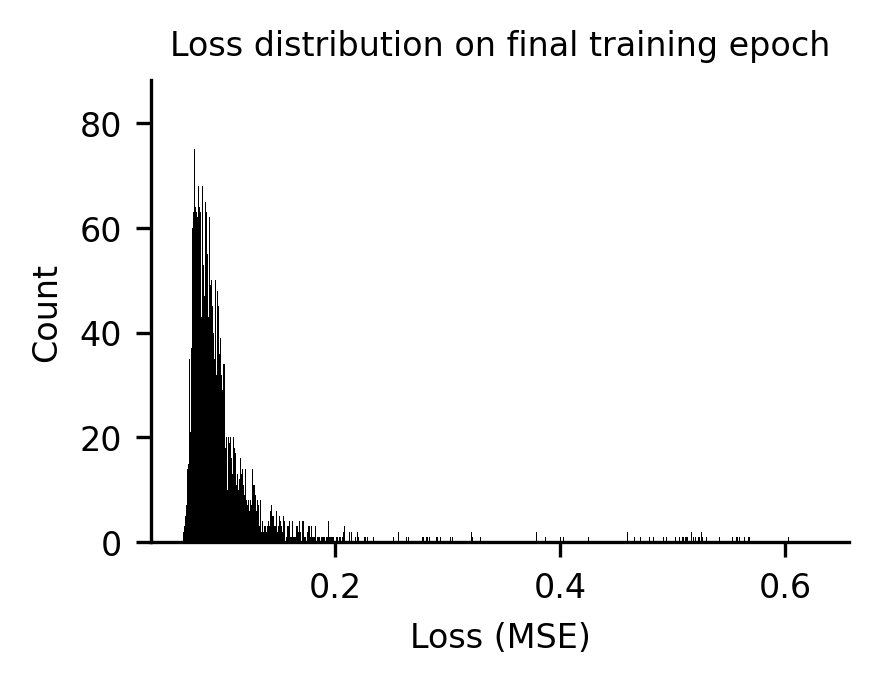

In [9]:
fig, ax = plt.subplots(figsize = (3,2))
ax.hist(optimizer.outputs['loss_decay'][-1], bins = 1000, color = 'black')
ax.tick_params(labelsize = fontsize)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel("Count", fontsize = fontsize)
ax.set_xlabel("Loss (MSE)", fontsize = fontsize)
#ax.set_xticks(np.arange(0,0.35,0.05))
#ax.set_ylim(0,60)
ax.set_title("Loss distribution on final training epoch", fontsize = fontsize)

In [ ]:
optimizer.outputs['param_history']['dLGN_params'][lsi[i],-1,0,:,:].shape

(4000, 5000, 2, 3, 7, 1, 1)

In [93]:
top_100_1 = []
for i in range(120):
    top_100_1.append(pd.DataFrame(optimizer.outputs['param_history']['dLGN_params'][lsi[i],-1,0,:,:,0,0]).corr(method='spearman').values)
top_100_1 = np.array(top_100_1)
top_100_2 = []
for i in range(120):
    top_100_2.append(pd.DataFrame(optimizer.outputs['param_history']['dLGN_params'][lsi[i],-1,1,:,:,0,0]).corr(method='spearman').values)
top_100_2 = np.array(top_100_2)

bottom_100_1 = []
for i in range(120):
    bottom_100_1.append(pd.DataFrame(optimizer.outputs['param_history']['dLGN_params'][lsi[i],-1,0,:,:,0,0]).corr(method='spearman').values)
bottom_100_1 = np.array(bottom_100_1)
bottom_100_2 = []
for i in range(120):
    bottom_100_2.append(pd.DataFrame(optimizer.outputs['param_history']['dLGN_params'][lsi[i],-1,0,:,:,0,0]).corr(method='spearman').values)
bottom_100_2 = np.array(bottom_100_2)

Text(0.525, 0.975, 'Distribution of dLGN parameters post-optimization')

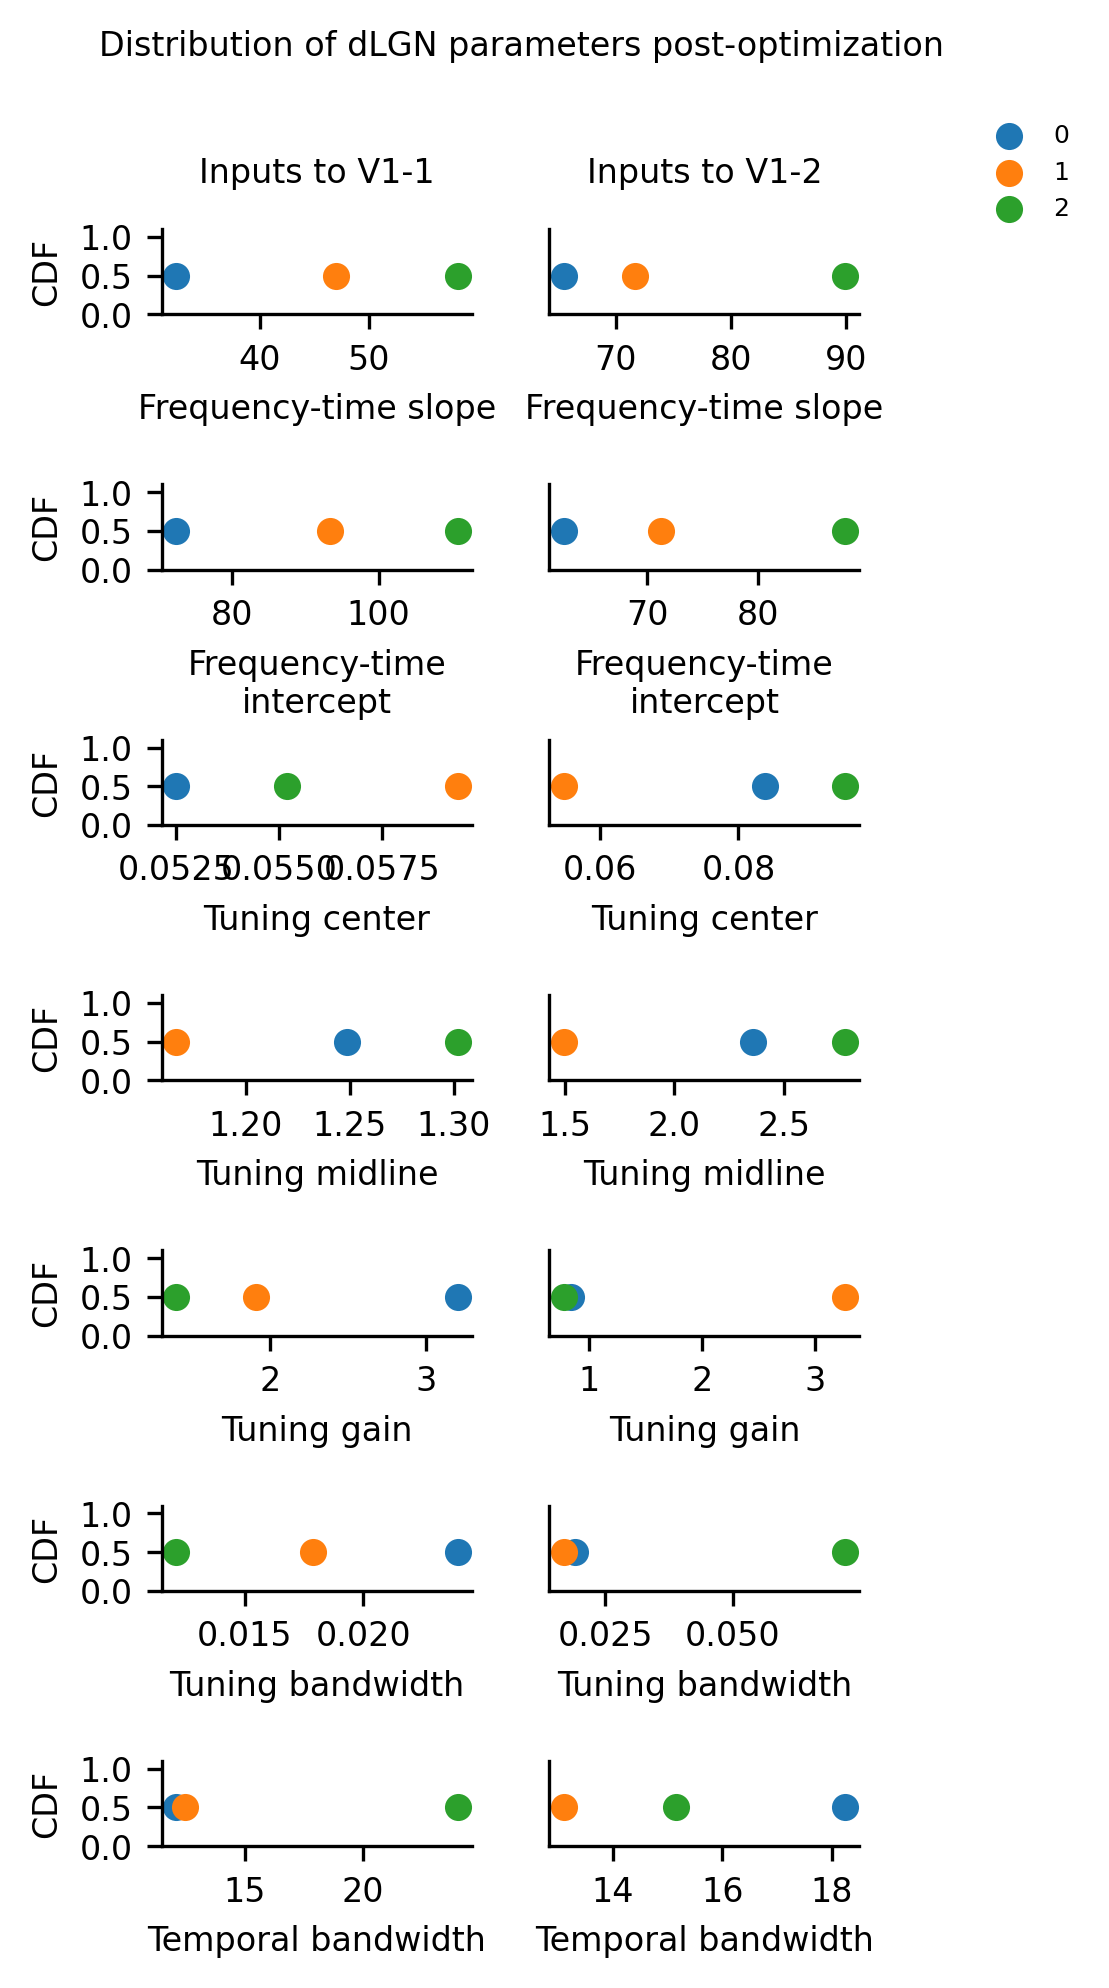

In [82]:
cmap = plt.get_cmap('tab10') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
fig, ax = plt.subplots(7,2, figsize = (3,7))

param_labels = [
    'Frequency-time slope',
    'Frequency-time\nintercept',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Temporal bandwidth'
]

neuron_labels = [f'dLGN_{i+1}' for i in range(3)]


for row in range(7):
    ymax = []
    for i in range(3):
        for u in range(2):
            ax[row, u].scatter(model.params['dLGN_params'][lsi[0], u, i, row, 0, 0], [0.5], label = i, linewidth = linewidth)
            ax[row, u].set_xlabel(param_labels[row], fontsize = fontsize)
            ax[row, u].tick_params(labelsize = fontsize)

    ax[row, 0].set_ylabel("CDF", fontsize = fontsize)
    for u in range(2):
        ax[row, u].set_ylim(0, 1.1)
        ax[row, 1].set_yticks([])
        ax[row, 0].set_yticks(np.arange(0, 1.5, 0.5))
        ax[row, u].spines['top'].set_visible(False)
        ax[row, u].spines['right'].set_visible(False)

fig.subplots_adjust(hspace = 2, wspace=0.25)
plt.tick_params(labelsize = 8)
ax[0,1].legend(fontsize = 6, bbox_to_anchor = (1.75,2.5), frameon = False)
ax[0,0].set_title("Inputs to V1-1", fontsize = fontsize, y = 1.25)
ax[0,1].set_title("Inputs to V1-2", fontsize = fontsize, y = 1.25)
plt.suptitle("Distribution of dLGN parameters post-optimization", fontsize = fontsize, x = 0.525, y = 0.975)


<Axes: >

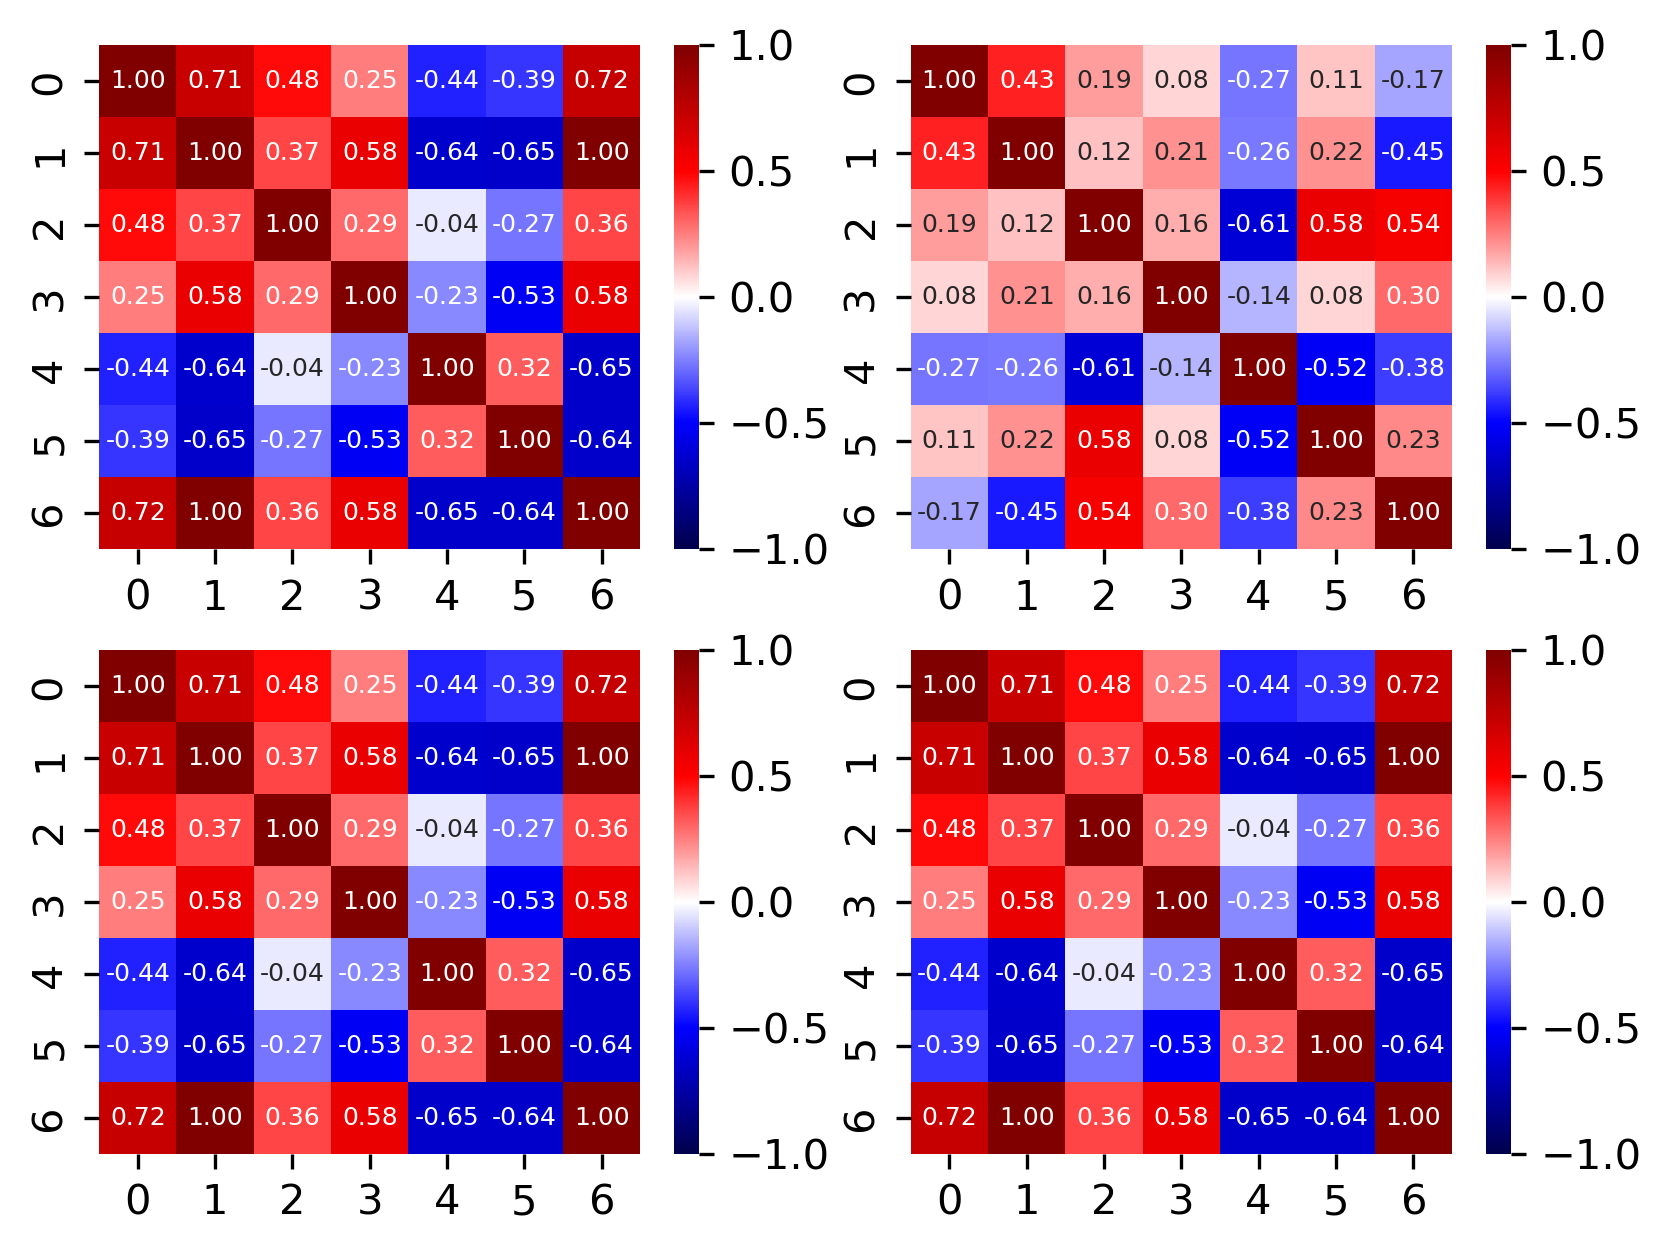

In [94]:
fig, ax = plt.subplots(2,2)

sns.heatmap(np.mean(top_100_1, 0), ax = ax[0,0], vmin = -1, vmax = 1, annot=True, fmt = '.2f', annot_kws = {'size': 6}, cmap = 'seismic')
sns.heatmap(np.mean(top_100_2, 0), ax = ax[0,1], vmin = -1, vmax = 1, annot=True, fmt = '.2f', annot_kws = {'size': 6}, cmap = 'seismic')

sns.heatmap(np.mean(bottom_100_1, 0), ax = ax[1,0], vmin = -1, vmax = 1, annot=True, fmt = '.2f', annot_kws = {'size': 6}, cmap = 'seismic')
sns.heatmap(np.mean(bottom_100_2, 0), ax = ax[1,1], vmin = -1, vmax = 1, annot=True, fmt = '.2f', annot_kws = {'size': 6}, cmap = 'seismic')

In [95]:
# params = optimizer.outputs['final_epoch_params']['dLGN_params'][:,:,:,:,0,0]
# op_perm = np.zeros((120, 7, 2, 3))
# for n in range(120):
#     for v in range(2):
#         for p in range(7):
#             for d in range(3):
#                 if params[lsi[n],v,d,p] == params[lsi[n],v,:,p].min():
#                     op_perm[n,p,v,d] = 0
#                 elif params[lsi[n],v,d,p] == params[lsi[n],v,:,p].max():
#                     op_perm[n,p,v,d] = 2
#                 if params[lsi[n],v,d,p] == np.median(params[lsi[n],v,:,p]):
#                     op_perm[n,p,v,d] = 1

In [96]:
params = optimizer.outputs['final_epoch_params']['dLGN_params'][lsi[:120],:,:,:,0,0]
op_perm = np.argsort(np.argsort(params, axis=2), axis=2).transpose(0,3,1,2)

P2 = tf.one_hot(
    op_perm,
    3,
    axis=-1,
)
P2 = tf.transpose(P2, (0,1,2,4,3))

P2 = tf.where(P2 == 1.0, 
                  tf.ones_like(P2) * 10.0,   # large positive
                  tf.ones_like(P2) * -10.0)  # large negative

#P = np.tile(P, [100, 1, 1, 1, 1, 1]).reshape(12000,7,2,3,3)

In [97]:
model2 = SGCCircuit(bounds=param_bounds, enforce_permutation=P2)
model2.initialize_random_parameters(2,3,120)

In [98]:
optimizer2 = Optimize(model2, epochs=5000, loss_threshold=0)
optimizer2.fit(X, Y_true)

Optimizer initialized with <keras.optimizers.optimizer_v2.adam.Adam object at 0x000002109A0AB490>
Training step = 0, N_exploration_samples = 120,
min_loss = 1.4206852912902832
med_loss = 10.212587356567383
max_loss = 48.619754791259766

Training step = 100, N_exploration_samples = 120,
min_loss = 0.9252269268035889
med_loss = 7.502862453460693
max_loss = 41.19839096069336

Training step = 200, N_exploration_samples = 120,
min_loss = 0.6589341163635254
med_loss = 5.670718669891357
max_loss = 34.54262924194336

Training step = 300, N_exploration_samples = 120,
min_loss = 0.4951542019844055
med_loss = 4.521852493286133
max_loss = 28.71097183227539

Training step = 400, N_exploration_samples = 120,
min_loss = 0.3891771137714386
med_loss = 3.5947093963623047
max_loss = 23.70699691772461

Training step = 500, N_exploration_samples = 120,
min_loss = 0.32042020559310913
med_loss = 2.855508327484131
max_loss = 19.495037078857422

Training step = 600, N_exploration_samples = 120,
min_loss = 0.27

<tf.Tensor: shape=(5000, 120), dtype=float16, numpy=
array([[23.02   , 32.78   , 13.89   , ..., 14.05   ,  5.66   ,  6.78   ],
       [22.97   , 32.72   , 13.86   , ..., 14.016  ,  5.645  ,  6.758  ],
       [22.9    , 32.66   , 13.82   , ..., 13.98   ,  5.625  ,  6.734  ],
       ...,
       [ 0.1703 ,  0.2563 ,  0.1136 , ...,  0.1184 ,  0.0816 ,  0.10046],
       [ 0.1702 ,  0.2563 ,  0.1136 , ...,  0.11835,  0.0816 ,  0.10046],
       [ 0.17   ,  0.2563 ,  0.1135 , ...,  0.11835,  0.0816 ,  0.10046]],
      dtype=float16)>

Text(0.525, 0.975, 'Distribution of dLGN parameters post-optimization')

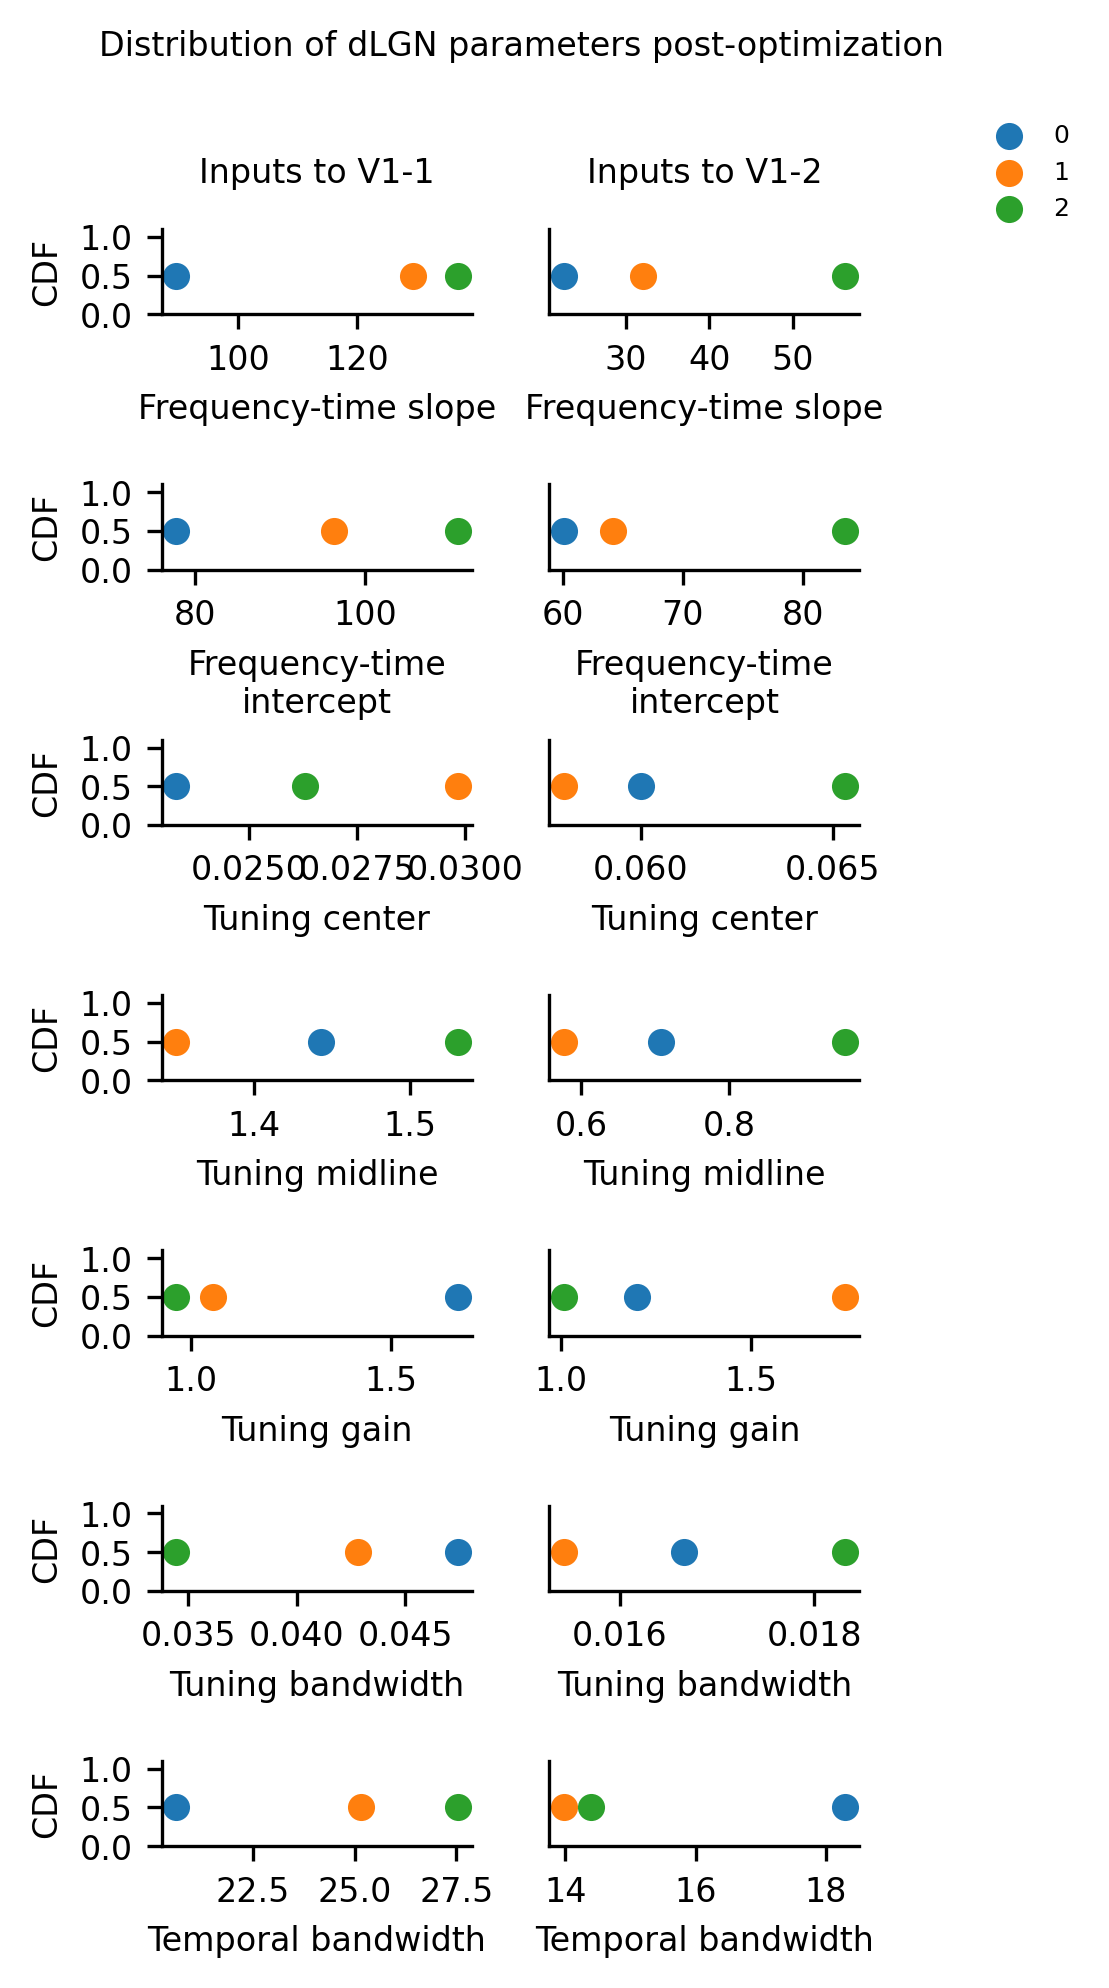

In [99]:
cmap = plt.get_cmap('tab10') 
rcParams['axes.prop_cycle'] = cycler(color=cmap(np.linspace(0, 1, 10)))
fig, ax = plt.subplots(7,2, figsize = (3,7))

param_labels = [
    'Frequency-time slope',
    'Frequency-time\nintercept',
    'Tuning center',
    'Tuning midline',
    'Tuning gain',
    'Tuning bandwidth',
    'Temporal bandwidth'
]

neuron_labels = [f'dLGN_{i+1}' for i in range(3)]


for row in range(7):
    ymax = []
    for i in range(3):
        for u in range(2):
            ax[row, u].scatter(model2.params['dLGN_params'][0, u, i, row, 0, 0], [0.5], label = i, linewidth = linewidth)
            ax[row, u].set_xlabel(param_labels[row], fontsize = fontsize)
            ax[row, u].tick_params(labelsize = fontsize)

    ax[row, 0].set_ylabel("CDF", fontsize = fontsize)
    for u in range(2):
        ax[row, u].set_ylim(0, 1.1)
        ax[row, 1].set_yticks([])
        ax[row, 0].set_yticks(np.arange(0, 1.5, 0.5))
        ax[row, u].spines['top'].set_visible(False)
        ax[row, u].spines['right'].set_visible(False)

fig.subplots_adjust(hspace = 2, wspace=0.25)
plt.tick_params(labelsize = 8)
ax[0,1].legend(fontsize = 6, bbox_to_anchor = (1.75,2.5), frameon = False)
ax[0,0].set_title("Inputs to V1-1", fontsize = fontsize, y = 1.25)
ax[0,1].set_title("Inputs to V1-2", fontsize = fontsize, y = 1.25)
plt.suptitle("Distribution of dLGN parameters post-optimization", fontsize = fontsize, x = 0.525, y = 0.975)


In [100]:
## sanity check

from scipy.stats import pearsonr
pearsonr(optimizer.outputs['param_history']['dLGN_params'][lsi[:120],-1,:,:,:,:,:].flatten(),
optimizer2.outputs['param_history']['dLGN_params'][:,-1,:,:,:,:,:].flatten())

PearsonRResult(statistic=0.9544324475569363, pvalue=0.0)

In [101]:
# for i in range(120):
#     fig, ax = plt.subplots()
#     plt.plot(optimizer.outputs['param_history']['dLGN_params'][lsi[i],-1,0,:,0,0,0], label = 1)
#     plt.plot(optimizer2.outputs['param_history']['dLGN_params'][i,-1,0,:,0,0,0], label = 2)
#     plt.legend()

In [102]:
optimizer2.outputs['final_epoch_params']['dLGN_params'][0,0,:,0,0,0]

array([ 0.04752,  0.53   , -1.32   ], dtype=float16)

In [103]:
pd.DataFrame(optimizer.outputs['param_history']['dLGN_params'][-1,0,0,:,:,0,0]).corr(method='pearson').values

array([[ 1.        ,  0.99897943, -0.45366418,  0.18378873,  0.47639768,
        -0.80024153, -0.50801638],
       [ 0.99897943,  1.        , -0.49345326,  0.2279993 ,  0.51562412,
        -0.77233886, -0.54640285],
       [-0.45366418, -0.49345326,  1.        , -0.95937064, -0.99967028,
        -0.17137559,  0.99807814],
       [ 0.18378873,  0.2279993 , -0.95937064,  1.        ,  0.95180944,
         0.44238739, -0.9400427 ],
       [ 0.47639768,  0.51562412, -0.99967028,  0.95180944,  1.        ,
         0.14602147, -0.99934024],
       [-0.80024153, -0.77233886, -0.17137559,  0.44238739,  0.14602147,
         1.        , -0.10999513],
       [-0.50801638, -0.54640285,  0.99807814, -0.9400427 , -0.99934024,
        -0.10999513,  1.        ]])

In [104]:
pd.DataFrame(optimizer2.outputs['param_history']['dLGN_params'][-1,0,0,:,:,0,0]).corr(method='pearson').values

array([[ 1.        ,  0.94298668,  0.86606014,  0.93936638, -0.50760743,
        -0.53625447,  0.97785601],
       [ 0.94298668,  1.        ,  0.98307838,  0.9999426 , -0.76542993,
        -0.22475316,  0.99175956],
       [ 0.86606014,  0.98307838,  1.        ,  0.98498472, -0.87036095,
        -0.04245123,  0.95150893],
       [ 0.93936638,  0.9999426 ,  0.98498472,  1.        , -0.7722811 ,
        -0.21429971,  0.99032994],
       [-0.50760743, -0.76542993, -0.87036095, -0.7722811 ,  1.        ,
        -0.45502248, -0.67667919],
       [-0.53625447, -0.22475316, -0.04245123, -0.21429971, -0.45502248,
         1.        , -0.34773654],
       [ 0.97785601,  0.99175956,  0.95150893,  0.99032994, -0.67667919,
        -0.34773654,  1.        ]])

In [107]:
top = []
for i in range(120):
    top.append(pd.DataFrame(optimizer.outputs['param_history']['dLGN_params'][lsi[i],-1,0,:,:,0,0]).corr(method='spearman').values)

<Axes: >

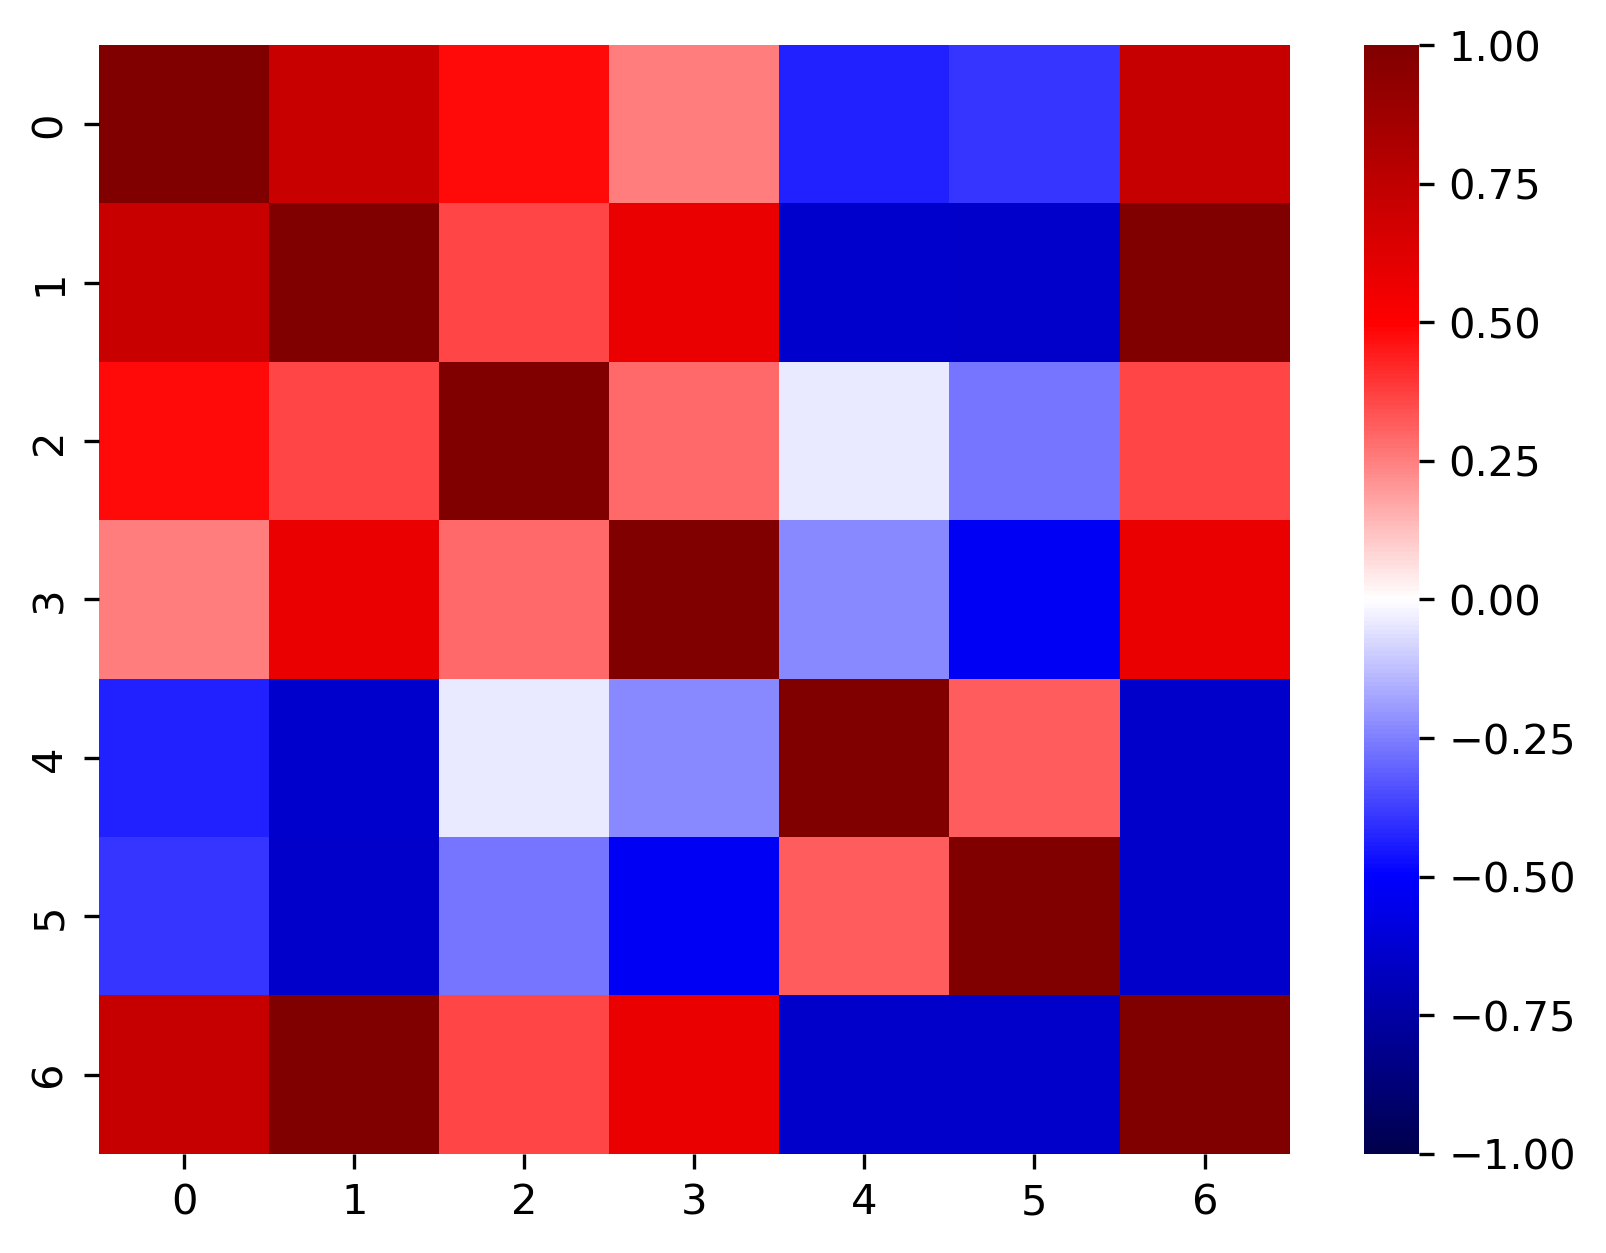

In [108]:
sns.heatmap(np.mean(top,0), vmin = -1, vmax = 1, cmap = 'seismic')

In [91]:
top = []
for i in range(120):
    top.append(pd.DataFrame(optimizer2.outputs['param_history']['dLGN_params'][i,-1,0,:,:,0,0]).corr(method='pearson').values)

<Axes: >

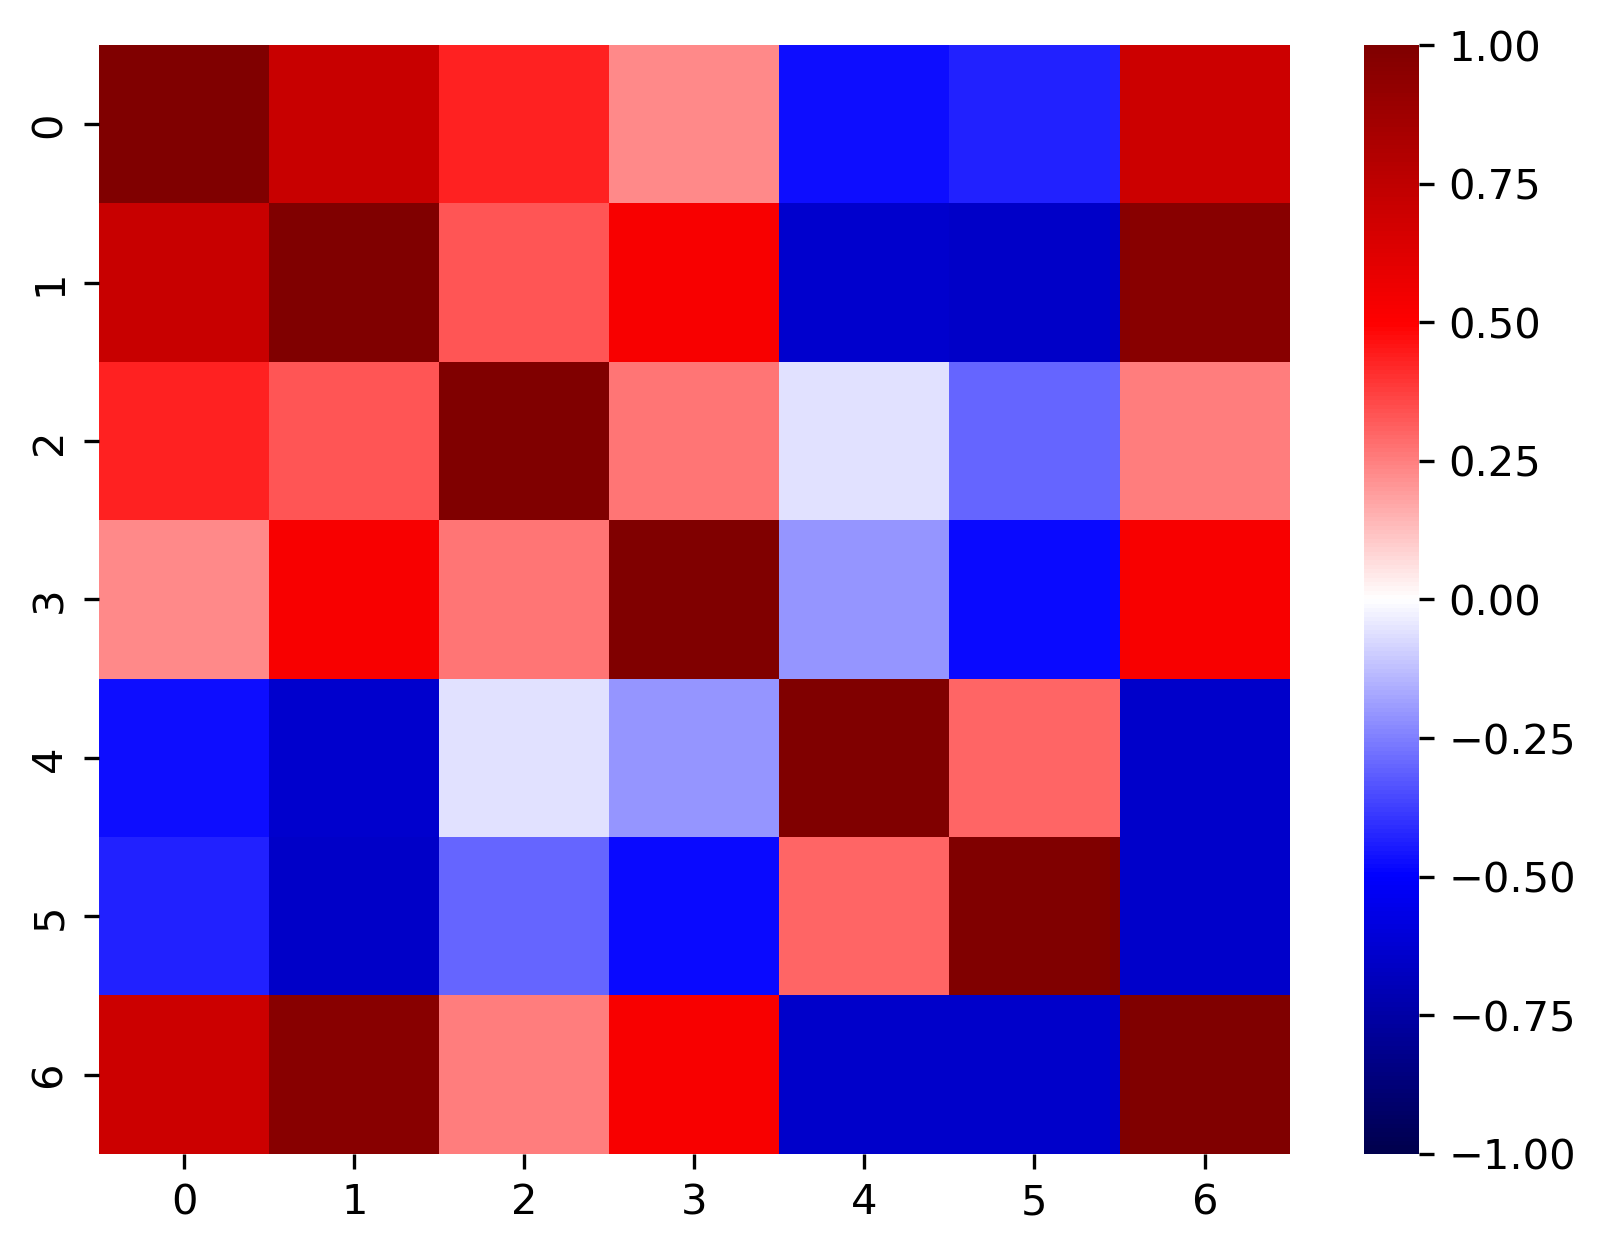

In [92]:
sns.heatmap(np.mean(top,0), vmin = -1, vmax = 1, cmap = 'seismic')